# Coastal Water Quality: Phase 2 Spectral Exploration

> Terms are defined in [`GLOSSARY.md`](./GLOSSARY.md). Phase 1 is [`01_explore_scene.ipynb`](./01_explore_scene.ipynb).

**Scene:** `20250302_030003_92_4001`, Borneo and the Makassar Strait coast.

## Objective
Phase 1 located the water and sediment plume. This notebook opens the **426-band surface-reflectance cube** and checks whether clear water, turbid water, and land separate in the spectra. It also checks for the green sediment peak, red chlorophyll absorption, and red-edge feature needed in Phase 3.

## This notebook
1. Reads the wavelength grid and `good_wavelengths` flags.
2. Builds valid, clean, water, clear-water, turbid-water, and land masks.
3. Maps the water mask and red-band turbidity proxy.
4. Compares group-mean spectra.
5. Checks that the turbid signal is water, not sand.
6. Checks glint with the black-pixel test.
7. Compares surface reflectance with TOA radiance.


## 0. Imports, paths, and cube helpers

The notebook locates the project root, points to the two HDF5 cubes, and defines memory-safe helpers.

- `cube_meta()` reads the wavelength grid, `good_wavelengths`, and FWHM attribute arrays.
- `read_band()` reads one 2-D band nearest a target wavelength and converts `_FillValue` to `NaN`.
- `stream_group_means()` makes one pass through all 426 bands to calculate mean spectra for pixel groups.

The cube grid is 850×810 in EPSG:32650 or UTM 50N. It matches `ortho_visual`, so a cube pixel at `(row, col)` is the same ground location as the Phase 1 RGB pixel.


In [16]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import h5py
import rasterio
from rasterio.warp import transform as warp_transform

def find_root(start=Path.cwd()):
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "data" / "inventory").exists():
            return cand
    return p

PROJECT_ROOT = find_root()
SCENE_ID = "20250302_030003_92_4001"
DATA_DIR = PROJECT_ROOT / "data" / "coastal" / SCENE_ID
FIG_DIR  = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SR_PATH  = DATA_DIR / "ortho_sr_hdf5.h5"          # surface reflectance (primary for water)
RAD_PATH = DATA_DIR / "ortho_radiance_hdf5.h5"    # TOA radiance (for the product comparison)
RGB_PATH = DATA_DIR / "ortho_visual.tif"
DF = "HDFEOS/GRIDS/HYP/Data Fields"               # HDF-EOS group holding every field
FILL = -9999.0

assert SR_PATH.exists(), f"Missing {SR_PATH} - run: python scripts/download_coastal.py --hdf5"

def cube_meta(path, var):
    "Return (wavelengths, good_wavelengths bool, fwhm) for a cube variable."
    with h5py.File(path, "r") as f:
        d = f[f"{DF}/{var}"]
        wl = np.asarray(d.attrs["wavelengths"], float)
        gw = np.asarray(d.attrs["good_wavelengths"]).astype(bool)
        fwhm = np.asarray(d.attrs["fwhm"], float)
    return wl, gw, fwhm

def read_band(path, var, wl, nm):
    "Read the single 2-D band nearest `nm` (NaN-filled). Returns (band_index, array)."
    i = int(np.argmin(np.abs(wl - nm)))
    with h5py.File(path, "r") as f:
        b = f[f"{DF}/{var}"][i].astype("float32")
    b[b == FILL] = np.nan
    return i, b

def stream_group_means(path, var, masks):
    "One streaming pass over all bands -> {group_name: mean_spectrum(426)}. Memory-safe."
    means = {k: np.full(426, np.nan) for k in masks}
    with h5py.File(path, "r") as f:
        d = f[f"{DF}/{var}"]
        for i in range(d.shape[0]):
            b = d[i].astype("float32")
            b[b == FILL] = np.nan
            for k, m in masks.items():
                means[k][i] = np.nanmean(b[m])
    return means

wl, gw, fwhm = cube_meta(SR_PATH, "surface_reflectance")
print(f"Cube: 426 bands, {wl[0]:.1f}-{wl[-1]:.1f} nm, FWHM ~{np.median(fwhm):.1f} nm")
print(f"good_wavelengths: {gw.sum()}/426 usable ({(~gw).sum()} flagged bad - mostly H2O-vapour bands)")


Cube: 426 bands, 376.4-2499.0 nm, FWHM ~6.0 nm
good_wavelengths: 368/426 usable (58 flagged bad - mostly H2O-vapour bands)


## 1. Wavelength grid: usable bands

Tanager records 426 bands from about 376 to 2499 nm. We exclude unreliable bands. Atmospheric water vapour absorbs most light around 1350 to 1450 nm and 1800 to 1950 nm, and the far SWIR is noisy. The `good_wavelengths` flag marks these bands as `0`, and plotted spectra leave them blank.

Water analysis uses the visible to near-infrared range, about 400 to 800 nm. Liquid water absorbs strongly beyond about 750 nm, so water should be dark in the NIR and SWIR. The later black-pixel check uses this property.

The figure shows good and flagged bands across the spectrum, then a VNIR view of the water-quality bands. Flagged bands should be concentrated in the atmospheric gaps rather than spread through the VNIR.


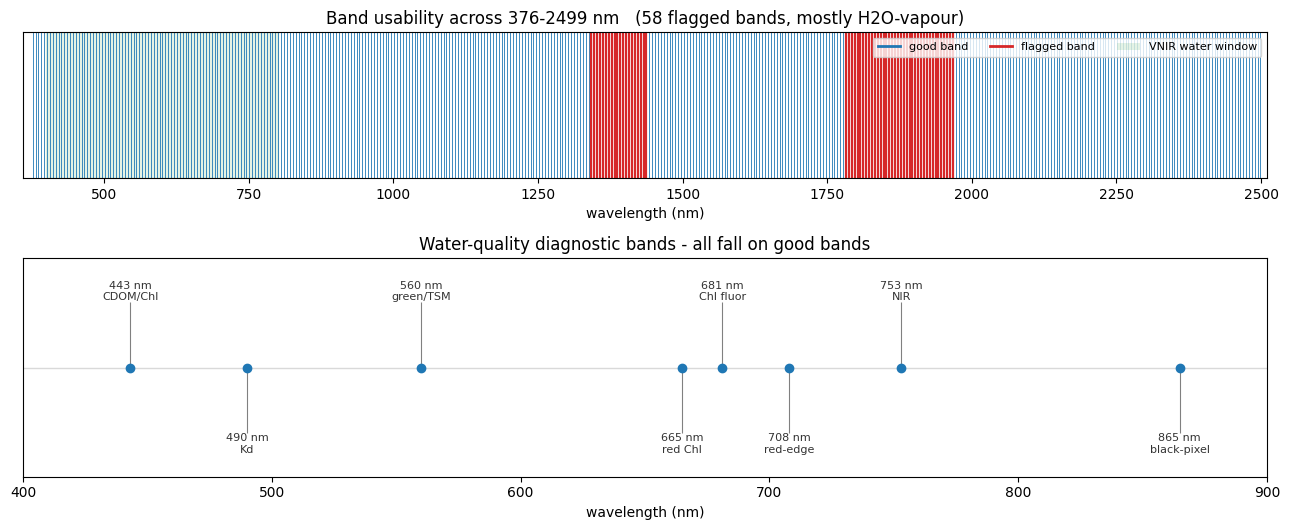

saved -> figures\02_wavelengths.png


In [17]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

DIAG = {443:"CDOM/Chl", 490:"Kd", 560:"green/TSM", 665:"red Chl", 681:"Chl fluor",
        708:"red-edge", 753:"NIR", 865:"black-pixel"}

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(13, 5.4),
                               gridspec_kw=dict(height_ratios=[1, 1.5]))

ax0.axvspan(400, 800, color="C2", alpha=0.12)
ax0.vlines(wl[gw],  0, 1, color="C0", lw=0.6)
ax0.vlines(wl[~gw], 0, 1, color="C3", lw=1.6)
ax0.set_xlim(360, 2510); ax0.set_ylim(0, 1); ax0.set_yticks([])
ax0.set_xlabel("wavelength (nm)")
ax0.set_title(f"Band usability across 376-2499 nm   ({(~gw).sum()} flagged bands, mostly H2O-vapour)")
ax0.legend(handles=[Line2D([0],[0], color="C0", lw=2, label="good band"),
                    Line2D([0],[0], color="C3", lw=2, label="flagged band"),
                    Patch(facecolor="C2", alpha=0.12, label="VNIR water window")],
           loc="upper right", fontsize=8, ncol=3)

ax1.set_xlim(400, 900); ax1.set_ylim(0, 1); ax1.set_yticks([])
ax1.axhline(0.5, color="0.85", lw=1); ax1.set_xlabel("wavelength (nm)")
ax1.set_title("Water-quality diagnostic bands - all fall on good bands")
for j, (nm, name) in enumerate(DIAG.items()):
    up = j % 2 == 0
    ytip = 0.80 if up else 0.20
    ax1.vlines(nm, 0.5, ytip, color="grey", lw=0.8)
    ax1.plot(nm, 0.5, "o", ms=6, color="C0")
    ax1.annotate(f"{nm} nm\n{name}", (nm, ytip), ha="center",
                 va="bottom" if up else "top", fontsize=8, color="0.2")

fig.tight_layout(); fig.savefig(FIG_DIR / "02_wavelengths.png", dpi=150, bbox_inches="tight")
plt.show(); print("saved ->", FIG_DIR / "02_wavelengths.png")


## 2. Masks: valid, clean, water, clear, and turbid

The masks progressively limit analysis to trusted pixels.

| Mask | Definition | Why |
|---|---|---|
| **valid** | `nodata_pixels == 0` and finite reflectance | removes the off-swath border |
| **clean** | valid and `beta_cloud_mask == 0` and `beta_cirrus_mask == 0` | removes cloud and cirrus |
| **water** | clean and `NDWI > 0`, where **NDWI = (Green₅₆₀ − NIR₈₆₁)/(Green₅₆₀ + NIR₈₆₁)** | keeps water and removes land |
| **clear / turbid** | water split at the 20th and 80th percentiles of red 665 nm reflectance | red brightening tracks suspended sediment |
| **land** | clean and `NDWI < −0.2` | provides a contrast class |

Only the 560, 665, and 861 nm bands and mask fields are read. The masks use surface reflectance. Here, clear water means optically deep water with low sediment, while turbid water represents the sediment plume.


In [18]:
ig, green = read_band(SR_PATH, "surface_reflectance", wl, 560)
ired, red = read_band(SR_PATH, "surface_reflectance", wl, 665)
inir, nir = read_band(SR_PATH, "surface_reflectance", wl, 861)

with h5py.File(SR_PATH, "r") as f:
    nodata = f[f"{DF}/nodata_pixels"][:]
    cloud  = f[f"{DF}/beta_cloud_mask"][:]
    cirrus = f[f"{DF}/beta_cirrus_mask"][:]

valid = (nodata == 0) & np.isfinite(green) & np.isfinite(nir)
clean = valid & (cloud == 0) & (cirrus == 0)
ndwi  = (green - nir) / (green + nir)
water = clean & (ndwi > 0)

red_w = np.where(water, red, np.nan)
p20, p80 = np.nanpercentile(red_w, [20, 80])
clear  = water & (red <= p20)
turbid = water & (red >= p80)
land   = clean & (ndwi < -0.2)

groups = {"clear": clear, "turbid": turbid, "land": land}
print(f"valid={valid.sum():,}  clean={clean.sum():,}  water={water.sum():,} "
      f"({100*water.sum()/clean.sum():.0f}% of clean)")
for k, m in groups.items():
    print(f"  {k:6s}: {m.sum():,} px")
print(f"turbidity split (red 665nm): clear<= {p20:.3f}, turbid>= {p80:.3f}")


valid=497,797  clean=484,752  water=208,741 (43% of clean)
  clear : 41,749 px
  turbid: 41,749 px
  land  : 262,854 px
turbidity split (red 665nm): clear<= 0.011, turbid>= 0.021


## 3. Maps: water mask and turbidity proxy

The three panels check whether the masks and sample points are sensible.

- **RGB with sample points:** the cyan clear-water point should be in dark open water and the red turbid-water point in visibly murky coastal water.
- **NDWI water mask:** water should be separated cleanly from land. Inland water-coloured specks or holes in the sea would indicate mask leakage.
- **Turbidity proxy:** red-band 665 nm reflectance is shown only over water. Warm colours indicate more suspended sediment. A real plume should form a smooth bright gradient from the Sangatta river mouth toward offshore water.


Representative sample points (row, col -> lon, lat):
  clear  (613,519) -> 117.6567, 0.4906
  turbid (401,500) -> 117.6516, 0.5481
  land   (128,337) -> 117.6077, 0.6222


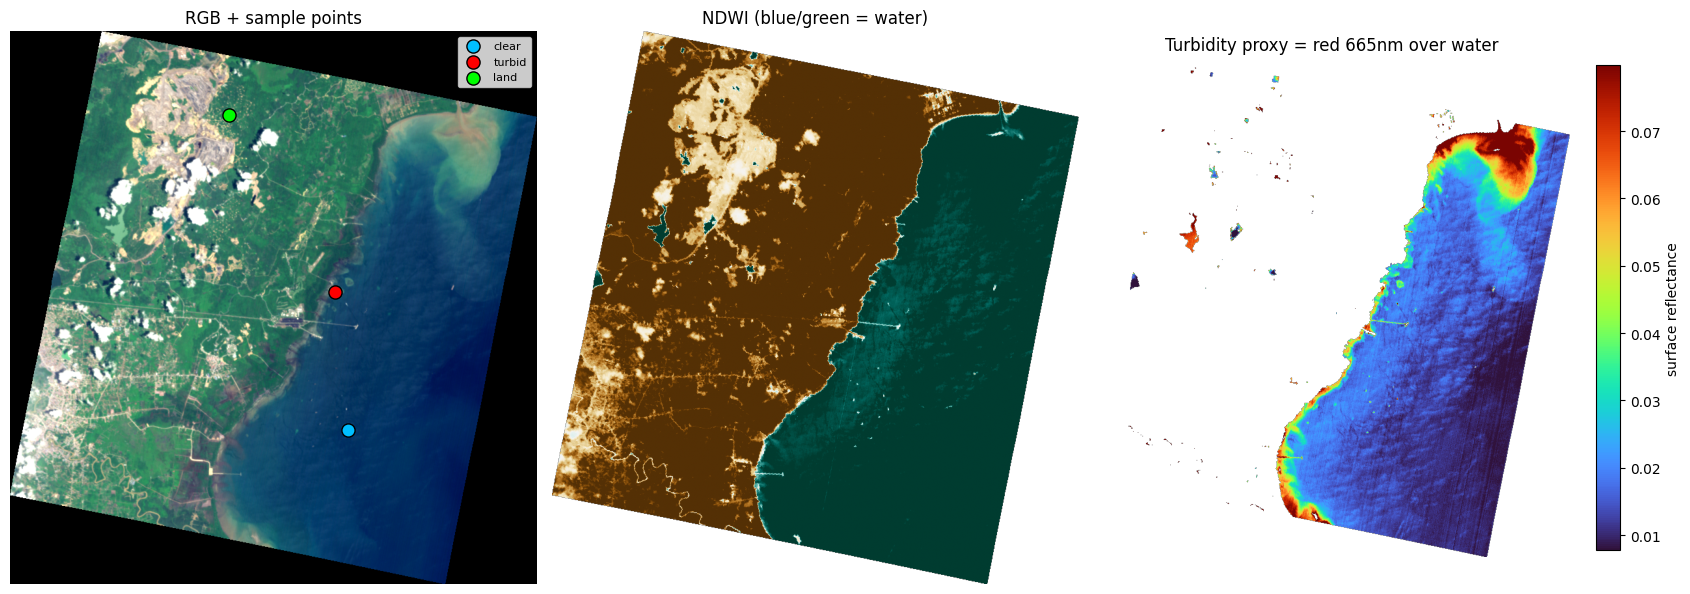

saved -> figures\02_water_masks.png


In [19]:
def rep_pixel(mask, score):
    "Pixel in `mask` whose score is closest to the group median (a robust representative)."
    rr, cc = np.where(mask)
    s = score[rr, cc]
    j = int(np.argmin(np.abs(s - np.nanmedian(s))))
    return rr[j], cc[j]

pts = {"clear": rep_pixel(clear, red), "turbid": rep_pixel(turbid, red),
       "land": rep_pixel(land, nir)}

# pixel -> lon/lat via the ortho_visual transform (UTM 50N -> WGS84)
with rasterio.open(RGB_PATH) as ds:
    rgb = np.dstack([ds.read(i) for i in (1, 2, 3)])
    tr, crs = ds.transform, ds.crs
print("Representative sample points (row, col -> lon, lat):")
for k, (rr, cc) in pts.items():
    x, y = rasterio.transform.xy(tr, rr, cc)
    lon, lat = warp_transform(crs, "EPSG:4326", [x], [y])
    print(f"  {k:6s} ({rr:3d},{cc:3d}) -> {lon[0]:.4f}, {lat[0]:.4f}")

turb_proxy = np.where(water, red, np.nan)
colors = {"clear": "deepskyblue", "turbid": "red", "land": "lime"}

fig, ax = plt.subplots(1, 3, figsize=(17, 6))
ax[0].imshow(np.clip(rgb / np.percentile(rgb[rgb > 0], 98), 0, 1)); ax[0].set_title("RGB + sample points")
for k, (rr, cc) in pts.items():
    ax[0].scatter(cc, rr, s=90, edgecolor="k", c=colors[k], label=k)
ax[0].legend(loc="upper right", fontsize=8)
ax[1].imshow(np.where(valid, ndwi, np.nan), cmap="BrBG", vmin=-0.6, vmax=0.6)
ax[1].set_title("NDWI (green/NIR = water)")
im = ax[2].imshow(turb_proxy, cmap="turbo", vmin=np.nanpercentile(turb_proxy, 2),
                  vmax=np.nanpercentile(turb_proxy, 98))
ax[2].set_title("Turbidity proxy = red 665nm over water")
fig.colorbar(im, ax=ax[2], fraction=0.046, label="surface reflectance")
for a in ax: a.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "02_water_masks.png", dpi=150, bbox_inches="tight")
plt.show(); print("saved ->", FIG_DIR / "02_water_masks.png")


## 4. Group-mean spectra: are the features present?

This is the main Phase 2 check. The notebook averages all clear-water, turbid-water, and land pixels into mean spectra. Averaging many pixels reduces random noise and stray glint.

- **Clear water** should be brightest in the blue, decline through the visible range, and approach zero past about 600 nm.
- **Turbid water** should be brighter because sediment scatters light. It should show a green peak near 560 nm, a dip near 665 nm, and a small red-edge shoulder near 700 to 710 nm.
- **Land** is only a contrast class. Vegetation should show a sharp red-edge rise near 700 nm and a high NIR plateau.

If clear and turbid water separate this way, the Phase 3 retrieval signals are present in the data.


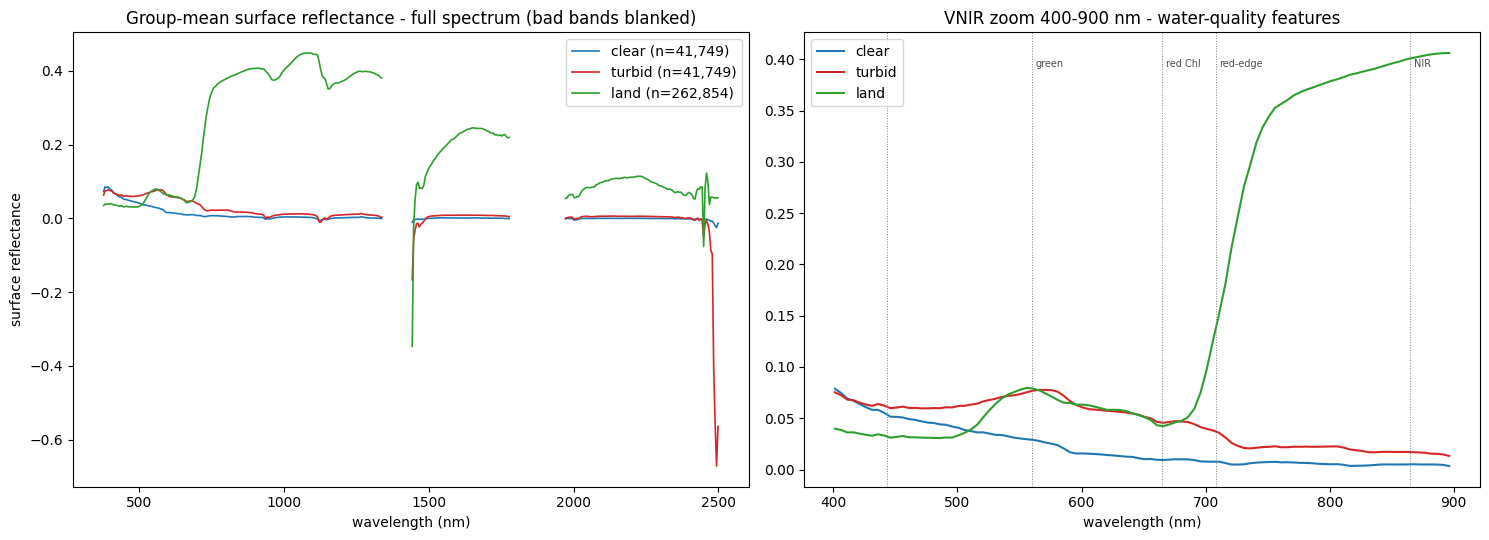

saved -> figures\02_group_spectra.png


In [20]:
means_sr = stream_group_means(SR_PATH, "surface_reflectance", groups)

def blank_bad(y):
    y = y.copy(); y[~gw] = np.nan; return y

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
for k, c in [("clear", "C0"), ("turbid", "C3"), ("land", "C2")]:
    ax[0].plot(wl, blank_bad(means_sr[k]), c, lw=1.2, label=f"{k} (n={groups[k].sum():,})")
ax[0].set_title("Group-mean surface reflectance - full spectrum (bad bands blanked)")
ax[0].set_xlabel("wavelength (nm)"); ax[0].set_ylabel("surface reflectance"); ax[0].legend()

sel = (wl >= 400) & (wl <= 900)
for k, c in [("clear", "C0"), ("turbid", "C3"), ("land", "C2")]:
    ax[1].plot(wl[sel], blank_bad(means_sr[k])[sel], c, lw=1.5, label=k)
for nm, name in {443:"", 560:"green", 665:"red Chl", 708:"red-edge", 865:"NIR"}.items():
    ax[1].axvline(nm, color="grey", ls=":", lw=0.7)
    if name: ax[1].text(nm+3, ax[1].get_ylim()[1]*0.92, name, fontsize=7, color="0.3")
ax[1].set_title("VNIR zoom 400-900 nm - water-quality features"); ax[1].set_xlabel("wavelength (nm)")
ax[1].legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "02_group_spectra.png", dpi=150, bbox_inches="tight")
plt.show(); print("saved ->", FIG_DIR / "02_group_spectra.png")


### Feature values

The plot needs numerical checks. For each group mean spectrum, the notebook calculates two indicators.

- **NDCI** = (R₇₀₈ − R₆₆₅)/(R₇₀₈ + R₆₆₅). Higher values indicate more chlorophyll-*a*.
- **Red/Green ratio** = R₆₆₅ / R₅₆₀, with the raw green and NIR levels. These rise with suspended sediment and track turbidity.

The clear-to-turbid rows show which signal dominates this scene.

**References used here**
- Mishra, S., & Mishra, D.R. (2012). *Normalized difference chlorophyll index: A novel model for remote estimation of chlorophyll-a concentration in turbid productive waters.* Remote Sensing of Environment, 117, 394–406. https://doi.org/10.1016/j.rse.2011.10.016. We use the **NDCI = (R₇₀₈ − R₆₆₅)/(R₇₀₈ + R₆₆₅)** formula as a chlorophyll-a indicator.
- Nechad, B., Ruddick, K.G., & Park, Y. (2010). *Calibration and validation of a generic multisensor algorithm for mapping of total suspended matter in turbid waters.* Remote Sensing of Environment, 114(4), 854–866. https://doi.org/10.1016/j.rse.2009.11.022. We use the red and green spectral response as a sediment indicator.


In [21]:
def at(spec, nm): return spec[int(np.argmin(np.abs(wl - nm)))]

print(f"{'group':8s} {'R443':>7} {'R560':>7} {'R665':>7} {'R708':>7} {'R861':>7} {'NDCI':>7} {'R665/560':>9}")
for k in ("clear", "turbid", "land"):
    s = means_sr[k]
    r443, r560, r665, r708, r861 = (at(s, nm) for nm in (443, 560, 665, 708, 861))
    ndci = (r708 - r665) / (r708 + r665)
    print(f"{k:8s} {r443:7.3f} {r560:7.3f} {r665:7.3f} {r708:7.3f} {r861:7.3f} {ndci:7.3f} {r665/r560:9.3f}")


group       R443    R560    R665    R708    R861    NDCI  R665/560
clear      0.055   0.029   0.009   0.008   0.005  -0.098     0.321
turbid     0.062   0.077   0.046   0.038   0.017  -0.090     0.594
land       0.033   0.079   0.042   0.125   0.400   0.497     0.534


## 5. Verification: is the turbid signal water, not sand?

Bright red values could come from suspended sediment, exposed sand or beach, or a shallow sandy seabed. The SWIR test separates these possibilities because liquid water absorbs SWIR strongly.

- **Turbid water** can be bright in green and red but should be near-black in the SWIR.
- **Sand and exposed land** stay bright across the spectrum, including the SWIR.

The notebook compares clear water, nearshore turbid water, offshore plume water, and sand or land. Near-black SWIR values in turbid areas confirm that the signal comes from water rather than exposed sand. The offshore plume also rules out a visible seabed.


group                R560    R665    R861  SWIR1610  SWIR2200  red/SWIR
clear water         0.029   0.009   0.005     0.001    -0.000       9.3   (n=41,749)
turbid nearshore    0.080   0.060   0.030     0.014     0.008       4.3   (n=7,368)
turbid offshore     0.076   0.039   0.014     0.007     0.005       5.2   (n=24,929)
bare/sand land      0.161   0.189   0.272     0.352     0.230       0.5   (n=9,173)


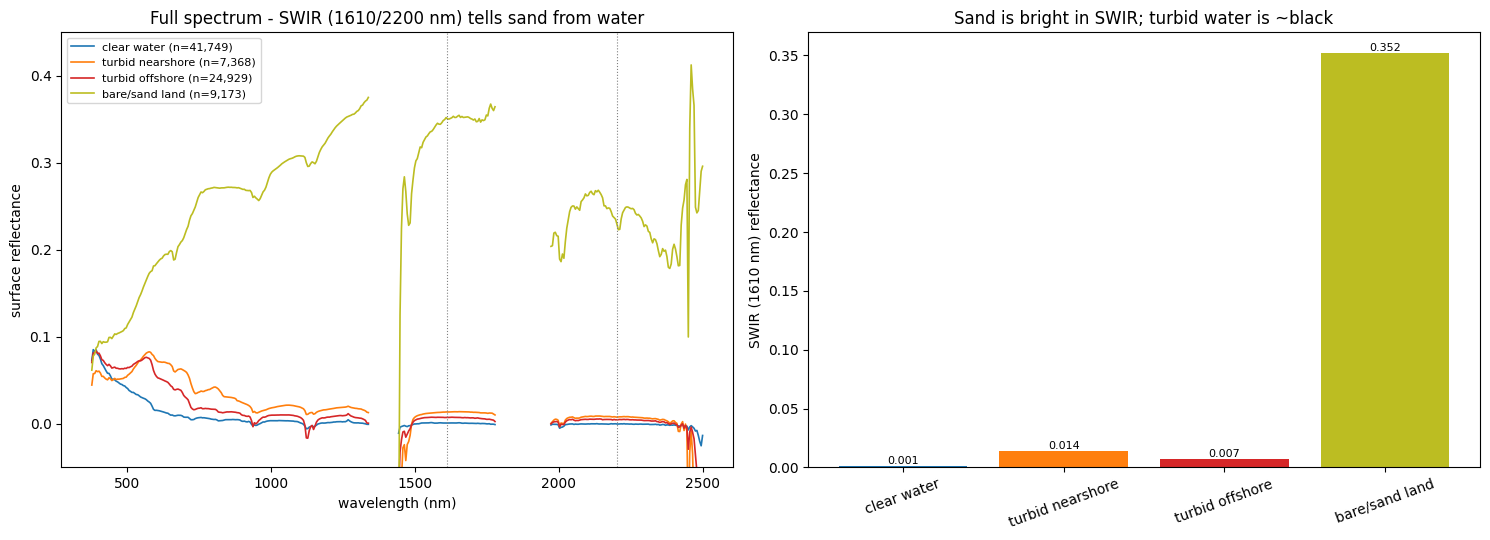

saved -> figures\02_sand_check.png


In [22]:
from scipy import ndimage

ndvi = (nir - red) / (nir + red)                       # green-ish vegetation index, to find bare/sand land
land = clean & (ndwi < -0.2)
dist = ndimage.distance_transform_edt(water)           # pixels to nearest non-water (shore distance)
red_w = np.where(water, red, np.nan)
p20v, p80v = np.nanpercentile(red_w, [20, 80])

checks = {
    "clear water":      water & (red <= p20v),
    "turbid nearshore": water & (red >= p80v) & (dist < 5),     # <~165 m from shore
    "turbid offshore":  water & (red >= p80v) & (dist > 15),    # deep open water (the river plume)
    "bare/sand land":   land & (ndvi < 0.25) & (red > 0.12),    # bright, non-vegetated land
}
cmeans = stream_group_means(SR_PATH, "surface_reflectance", checks)    # one pass, ~30-40 s

print(f"{'group':17s} {'R560':>7} {'R665':>7} {'R861':>7} {'SWIR1610':>9} {'SWIR2200':>9} {'red/SWIR':>9}")
for k, m in checks.items():
    s = cmeans[k]
    print(f"{k:17s} {at(s,560):7.3f} {at(s,665):7.3f} {at(s,861):7.3f} {at(s,1610):9.3f} {at(s,2200):9.3f} "
          f"{at(s,665)/max(at(s,1610),1e-4):9.1f}   (n={int(m.sum()):,})")

colors = {"clear water":"C0", "turbid nearshore":"C1", "turbid offshore":"C3", "bare/sand land":"C8"}
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
for k in checks:
    ax[0].plot(wl, blank_bad(cmeans[k]), colors[k], lw=1.2, label=f"{k} (n={int(checks[k].sum()):,})")
for x in (1610, 2200): ax[0].axvline(x, color="grey", ls=":", lw=0.8)
ax[0].set_ylim(-0.05, 0.45)        # clip noisy near-zero SWIR spikes at the bad-band edges
ax[0].set_title("Full spectrum - SWIR (1610/2200 nm) tells sand from water")
ax[0].set_xlabel("wavelength (nm)"); ax[0].set_ylabel("surface reflectance"); ax[0].legend(fontsize=8)

swir_vals = [at(cmeans[k], 1610) for k in checks]
bars = ax[1].bar(list(checks), swir_vals, color=[colors[k] for k in checks])
ax[1].set_ylabel("SWIR (1610 nm) reflectance"); ax[1].set_title("Sand is bright in SWIR; turbid water is ~black")
ax[1].tick_params(axis="x", rotation=20)
for b, vv in zip(bars, swir_vals):
    ax[1].text(b.get_x() + b.get_width()/2, vv, f"{vv:.3f}", ha="center", va="bottom", fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "02_sand_check.png", dpi=150, bbox_inches="tight")
plt.show(); print("saved ->", FIG_DIR / "02_sand_check.png")


**References used here**
- Xu, H. (2006). *Modification of normalised difference water index (NDWI) to enhance open water features in remotely sensed imagery.* International Journal of Remote Sensing, 27(14), 3025–3033. https://doi.org/10.1080/01431160600589179. We use the established principle behind **MNDWI**: SWIR separates dark water from bright land or sand.


## 6. Glint and black-pixel check

Water absorbs near-infrared light, so clear water should be almost black near 861 nm. Extra NIR brightness can indicate sun glint or incomplete atmospheric correction. This black-pixel assumption also supports standard ocean-colour atmospheric correction and NIR-based glint removal.

The notebook plots the NIR reflectance distribution for water pixels and reports the clear-water median, the fraction above a glint threshold, and the sun and sensor angles. A clean scene has a narrow distribution near zero. A long bright tail would indicate glint or another correction issue.


clear-water NIR(861) reflectance: median=0.0048  (want ~0)
water pixels with NIR > 0.02: 3.0%  (potential residual glint/turbidity)
sun zenith  ~21.7 deg   sensor zenith ~9.2 deg


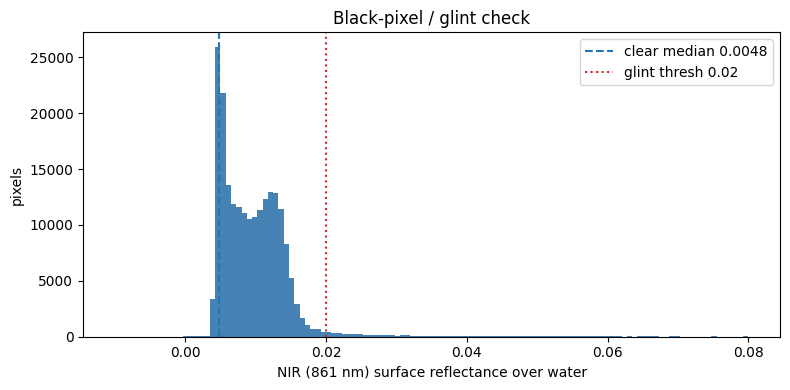

saved -> figures\02_glint_check.png


In [23]:
nir_water = nir[water]
nir_clear = nir[clear]
glint_thresh = 0.02
frac_glint = 100 * np.mean(nir_water > glint_thresh)

with h5py.File(SR_PATH, "r") as f:
    sz = f[f"{DF}/sun_zenith"][:];    sz = sz[sz != FILL]
    vz = f[f"{DF}/sensor_zenith"][:]; vz = vz[vz != FILL]

print(f"clear-water NIR(861) reflectance: median={np.nanmedian(nir_clear):.4f}  (want ~0)")
print(f"water pixels with NIR > {glint_thresh}: {frac_glint:.1f}%  (potential residual glint/turbidity)")
print(f"sun zenith  ~{np.nanmedian(sz):.1f} deg   sensor zenith ~{np.nanmedian(vz):.1f} deg")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(nir_water[np.isfinite(nir_water)], bins=120, range=(-0.01, 0.08), color="steelblue")
ax.axvline(np.nanmedian(nir_clear), color="C0", ls="--", label=f"clear median {np.nanmedian(nir_clear):.4f}")
ax.axvline(glint_thresh, color="C3", ls=":", label=f"glint thresh {glint_thresh}")
ax.set_xlabel("NIR (861 nm) surface reflectance over water"); ax.set_ylabel("pixels")
ax.set_title("Black-pixel / glint check"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "02_glint_check.png", dpi=150, bbox_inches="tight")
plt.show(); print("saved ->", FIG_DIR / "02_glint_check.png")


## 7. Product decision: surface reflectance or TOA radiance

The scene provides `ortho_sr_hdf5` surface reflectance, with atmospheric effects removed, and `ortho_radiance_hdf5` top-of-atmosphere radiance in `W·m⁻²·sr⁻¹·µm⁻¹`. The comparison uses clear-water and turbid-water mean spectra from both products.

Radiance preserves the clear-to-turbid difference, but its shape is dominated by sunlight and atmosphere, including the oxygen absorption feature near 760 nm. Radiance values cannot be compared directly between scenes. Surface reflectance removes that envelope, making the green sediment peak and red-edge shoulder clearer. Surface reflectance is therefore the primary input for the water analysis.


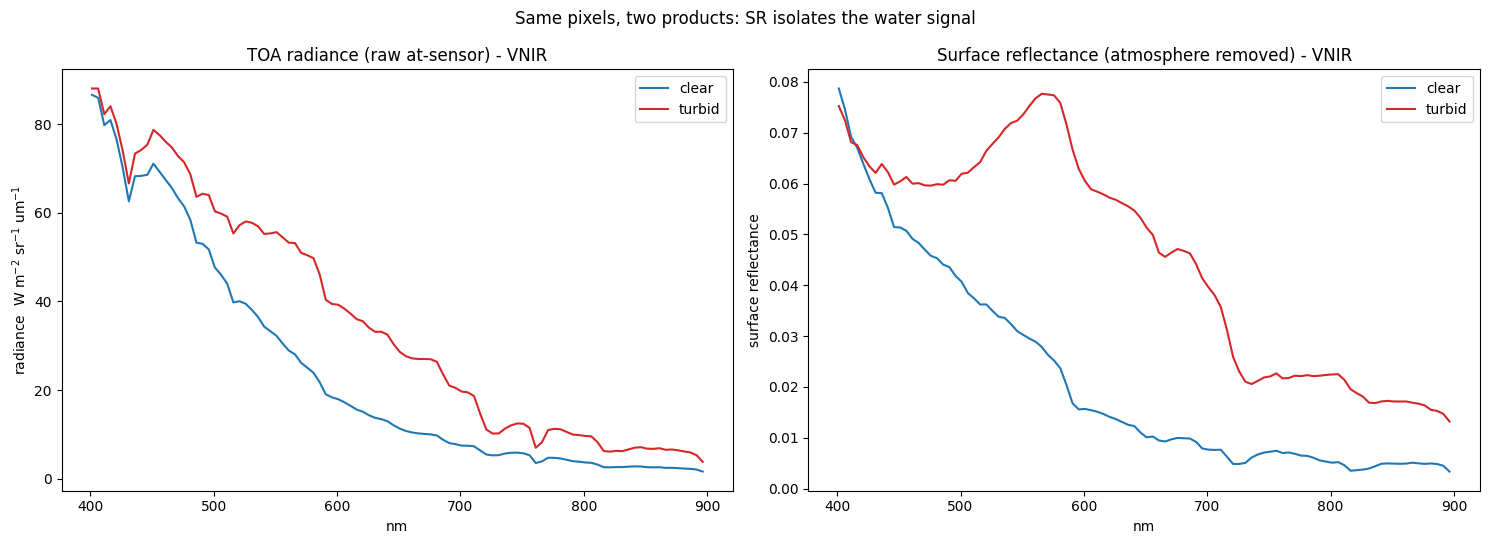

saved -> figures\02_rad_vs_sr.png


In [24]:
two = {"clear": clear, "turbid": turbid}
means_rad = stream_group_means(RAD_PATH, "toa_radiance", two)

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
sel = (wl >= 400) & (wl <= 900)
for k, c in [("clear", "C0"), ("turbid", "C3")]:
    ax[0].plot(wl[sel], blank_bad(means_rad[k])[sel], c, lw=1.5, label=k)
ax[0].set_title("TOA radiance (raw at-sensor) - VNIR"); ax[0].set_xlabel("nm")
ax[0].set_ylabel("radiance  W m$^{-2}$ sr$^{-1}$ um$^{-1}$"); ax[0].legend()

sel = (wl >= 400) & (wl <= 900)
for k, c in [("clear", "C0"), ("turbid", "C3")]:
    ax[1].plot(wl[sel], blank_bad(means_sr[k])[sel], c, lw=1.5, label=k)
ax[1].set_title("Surface reflectance (atmosphere removed) - VNIR"); ax[1].set_xlabel("nm")
ax[1].set_ylabel("surface reflectance"); ax[1].legend()
fig.suptitle("Same pixels, two products: SR isolates the water signal", fontsize=12)
fig.tight_layout(); fig.savefig(FIG_DIR / "02_rad_vs_sr.png", dpi=150, bbox_inches="tight")
plt.show(); print("saved ->", FIG_DIR / "02_rad_vs_sr.png")


## Summary and hand-off to Phase 3

**Phase 2 established**
- 368 of 426 bands are usable. Water analysis stays in the VNIR, about 400 to 800 nm, and ignores water-vapour bands.
- NDWI separates about 40% of clean pixels as water. Red reflectance separates clear and turbid water.
- Turbid water has a green sediment peak, a 665 nm dip, and a red-edge shoulder. Clear water is near-black past about 600 nm.
- Turbid regions are near-black in the SWIR, about 0.01, while sand is bright, about 0.35. The plume is suspended sediment in water, not sand or a visible seabed.
- Clear-water NIR is near zero, indicating low residual glint and effective atmospheric correction.
- Surface reflectance isolates the water signal. TOA radiance does not, so surface reflectance is the primary product.

**Figures:** `02_wavelengths.png`, `02_water_masks.png`, `02_group_spectra.png`, `02_sand_check.png`, `02_glint_check.png`, `02_rad_vs_sr.png`.

**Next:** [`03_water_quality.ipynb`](./03_water_quality.ipynb) applies relative turbidity, chlorophyll, and CDOM retrievals over the water mask and plots a river-mouth-to-offshore transect.
